# TASK 9

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from mpl_toolkits.mplot3d import Axes3D

In [2]:
data = pd.read_csv("IRIS.csv")

print(data.head(15))

    sepal_length  sepal_width  petal_length  petal_width      species
0            5.1          3.5           1.4          0.2  Iris-setosa
1            4.9          3.0           1.4          0.2  Iris-setosa
2            4.7          3.2           1.3          0.2  Iris-setosa
3            4.6          3.1           1.5          0.2  Iris-setosa
4            5.0          3.6           1.4          0.2  Iris-setosa
5            5.4          3.9           1.7          0.4  Iris-setosa
6            4.6          3.4           1.4          0.3  Iris-setosa
7            5.0          3.4           1.5          0.2  Iris-setosa
8            4.4          2.9           1.4          0.2  Iris-setosa
9            4.9          3.1           1.5          0.1  Iris-setosa
10           5.4          3.7           1.5          0.2  Iris-setosa
11           4.8          3.4           1.6          0.2  Iris-setosa
12           4.8          3.0           1.4          0.1  Iris-setosa
13           4.3    

## Plot the distribution of all four feature in single 3D plot

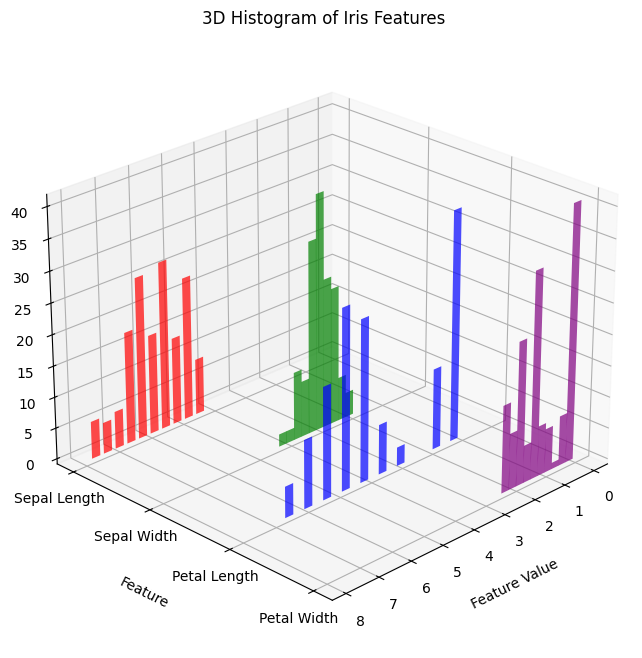

In [3]:
X = data[['sepal_length','sepal_width','petal_length','petal_width']].values

fig = plt.figure(figsize=(14,8))
ax = fig.add_subplot(111, projection='3d')

colors = ['red','green','blue','purple']
feature_names = ['Sepal Length','Sepal Width','Petal Length','Petal Width']

for i in range(4):

    hist, bins = np.histogram(X[:,i], bins=10)

    xs = (bins[:-1] + bins[1:]) / 2

    ax.bar(xs,
           hist,
           zs=i,
           zdir='y',
           color=colors[i],
           alpha=0.7,
           width=0.25)

ax.set_xlabel('Feature Value', labelpad=10)
ax.set_ylabel('Feature', labelpad=15)
ax.set_zlabel('Frequency', labelpad=10)

ax.set_yticks([0,1,2,3])
ax.set_yticklabels(feature_names)

ax.view_init(elev=25, azim=45)

plt.title("3D Histogram of Iris Features")

plt.show()

##  Plot the distribution of all four feature in single 3D plot. (Density estimation)

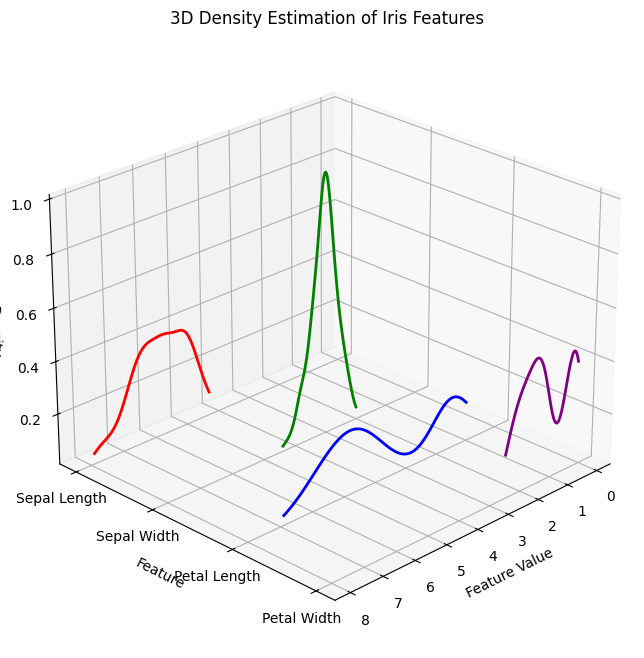

In [4]:
features = ['sepal_length','sepal_width','petal_length','petal_width']

fig = plt.figure(figsize=(14,8))
ax = fig.add_subplot(111, projection='3d')

colors = ['red','green','blue','purple']

for i, feature in enumerate(features):

    values = data[feature]

    # density estimation
    density = gaussian_kde(values)

    xs = np.linspace(values.min(), values.max(), 100)
    ys = density(xs)

    ax.plot(xs, ys, zs=i, zdir='y', color=colors[i], linewidth=2)
    
ax.set_xlabel('Feature Value')
ax.set_ylabel('Feature')
ax.set_zlabel('Density')

ax.set_yticks([0,1,2,3])
ax.set_yticklabels(['Sepal Length','Sepal Width','Petal Length','Petal Width'])

ax.view_init(elev=25, azim=45)

plt.title("3D Density Estimation of Iris Features")

plt.show()

## Visualize the distribution with respect to all three classes by considering two features

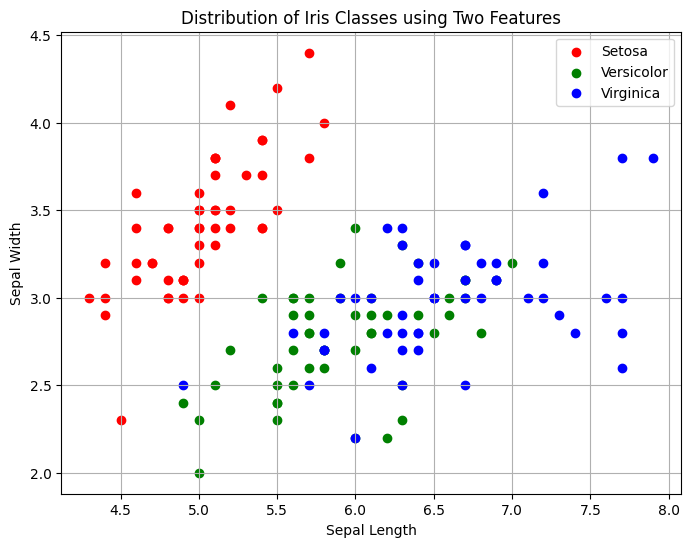

In [5]:
x = data['sepal_length']
y = data['sepal_width']

# Classes
setosa = data[data['species'] == 'Iris-setosa']
versicolor = data[data['species'] == 'Iris-versicolor']
virginica = data[data['species'] == 'Iris-virginica']

plt.figure(figsize=(8,6))

plt.scatter(setosa['sepal_length'], setosa['sepal_width'],
            color='red', label='Setosa')

plt.scatter(versicolor['sepal_length'], versicolor['sepal_width'],
            color='green', label='Versicolor')

plt.scatter(virginica['sepal_length'], virginica['sepal_width'],
            color='blue', label='Virginica')

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")

plt.title("Distribution of Iris Classes using Two Features")

plt.legend()
plt.grid(True)

plt.show()

## Visualize the distribution with respect to all three classes by considering three features

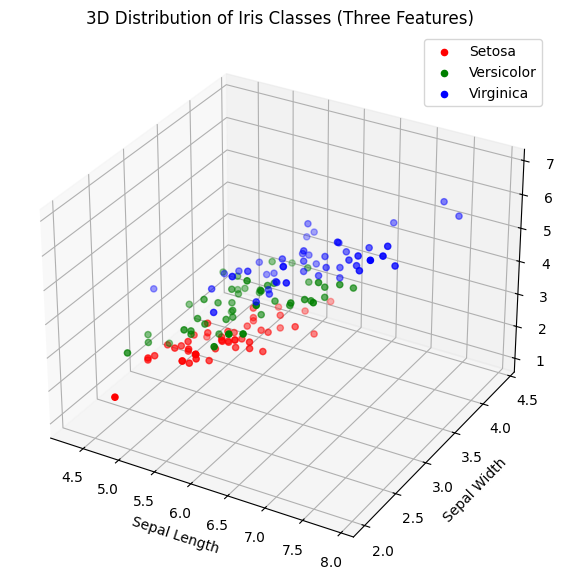

In [6]:
setosa = data[data['species'] == 'Iris-setosa']
versicolor = data[data['species'] == 'Iris-versicolor']
virginica = data[data['species'] == 'Iris-virginica']

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(setosa['sepal_length'],
           setosa['sepal_width'],
           setosa['petal_length'],
           color='red',
           label='Setosa')

ax.scatter(versicolor['sepal_length'],
           versicolor['sepal_width'],
           versicolor['petal_length'],
           color='green',
           label='Versicolor')

ax.scatter(virginica['sepal_length'],
           virginica['sepal_width'],
           virginica['petal_length'],
           color='blue',
           label='Virginica')

ax.set_xlabel("Sepal Length")
ax.set_ylabel("Sepal Width")
ax.set_zlabel("Petal Length")

plt.title("3D Distribution of Iris Classes (Three Features)")

ax.legend()

plt.show()